# Explainability Method Comparison for Diabetic Retinopathy Diagnosis

**Research Question:** Do Grad-CAM, SHAP, and LIME highlight the same retinal
regions when explaining a diabetic retinopathy prediction? Which method is most
clinically informative?

**Methods compared:**
- **Grad-CAM** — gradient-weighted class activation mapping (fast, class-discriminative)
- **SHAP** — SHapley Additive exPlanations via GradientExplainer (theoretically grounded)
- **LIME** — Local Interpretable Model-agnostic Explanations (superpixel-based)

**Dataset:** APTOS 2019 Blindness Detection — 5-class DR severity (0–4)
**Model:** EfficientNet-B4 fine-tuned on APTOS 2019

## 1. Setup

In [4]:
import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from pathlib import Path

import torch
import torch.nn.functional as F
from torchvision import transforms

# Explainability
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import shap
from lime import lime_image
from skimage.segmentation import mark_boundaries

warnings.filterwarnings("ignore")

# Add project root to path — works in both .py scripts and Jupyter notebooks
try:
    ROOT = Path(__file__).resolve().parents[1]
except NameError:
    # __file__ is undefined in Jupyter — walk up from cwd until we find src/
    ROOT = Path(os.getcwd())
    while not (ROOT / "src").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent

sys.path.insert(0, str(ROOT))

from src.predict import load_model, inference_transforms, CLASS_NAMES
from src.config import SAVE_PATH, TRAIN_CSV, TRAIN_IMGS

plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("All imports OK")
print(f"PyTorch: {torch.__version__}")

All imports OK
PyTorch: 2.10.0+cpu


## 2. Load Model

In [5]:
model, device = load_model(SAVE_PATH)
print(f"Model loaded on {device}")

Model loaded from e:\Portfolio\Medical_Imaging_Diagnosis_API\models\best_model.pth on cpu
Model loaded on cpu


## 3. Sample Images — 3 per DR Severity Class

In [6]:
df = pd.read_csv(TRAIN_CSV)
print(f"Dataset: {len(df)} images across {df['diagnosis'].nunique()} classes")
print(df['diagnosis'].value_counts().sort_index())

Dataset: 2930 images across 5 classes
diagnosis
0    1434
1     300
2     808
3     154
4     234
Name: count, dtype: int64


In [8]:
N_PER_CLASS = 3
SEED        = 42

samples = (
    df.groupby("diagnosis")
      .apply(lambda g: g.sample(min(N_PER_CLASS, len(g)), random_state=SEED))
      .reset_index(drop=True)
)

print(f"Selected {len(samples)} images ({N_PER_CLASS} per class)")
samples.head(10)

Selected 15 images (3 per class)


,id_code,diagnosis
0,51aa3361294c,0
1,6de39b94f634,0
2,aa8a1e814811,0
3,a32886cb31ab,1
4,ca7140ecf389,1
5,7b20210d9120,1
6,c8905b8d5cf1,2
7,5e7cc6ab4ac4,2
8,4ed31cc07366,2
9,3435fd8675a2,3


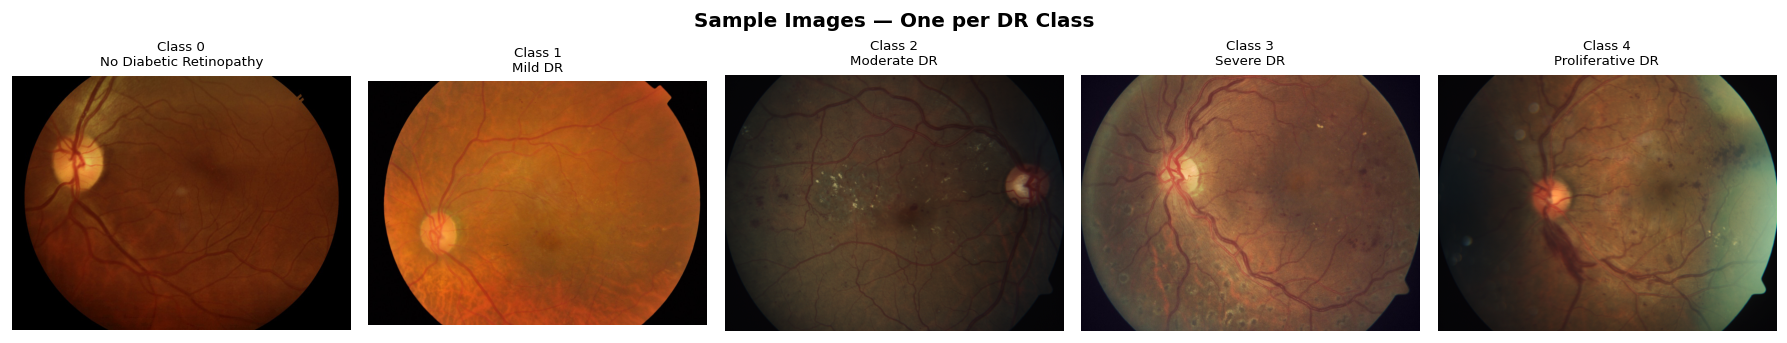

In [9]:
def load_image(id_code):
    path = os.path.join(TRAIN_IMGS, id_code + ".png")
    return Image.open(path).convert("RGB")

# Quick preview of one image per class
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for cls in range(5):
    row  = samples[samples["diagnosis"] == cls].iloc[0]
    img  = load_image(row["id_code"])
    axes[cls].imshow(img)
    axes[cls].set_title(f"Class {cls}\n{CLASS_NAMES[cls]}", fontsize=8)
    axes[cls].axis("off")
plt.suptitle("Sample Images — One per DR Class", fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Helper — Preprocessing & Prediction

In [ ]:
IMG_SIZE = 224

def preprocess(image: Image.Image) -> torch.Tensor:
    """Return normalised tensor [1, 3, H, W]."""
    return inference_transforms(image).unsqueeze(0).to(device)

def predict(image: Image.Image) -> dict:
    tensor = preprocess(image)
    with torch.no_grad():
        logits = model(tensor)
        probs  = F.softmax(logits, dim=1).squeeze().cpu().numpy()
    cls = int(np.argmax(probs))
    return {"class": cls, "name": CLASS_NAMES[cls], "confidence": probs[cls], "probs": probs}

def img_to_array(image: Image.Image) -> np.ndarray:
    """Return float32 array in [0, 1] at model input size."""
    return np.array(image.resize((IMG_SIZE, IMG_SIZE)), dtype=np.float32) / 255.0

## 5. Grad-CAM

In [ ]:
def run_gradcam(image: Image.Image, target_class: int) -> np.ndarray:
    """Return Grad-CAM heatmap overlaid on image (H×W×3 float32)."""
    target_layer = [model.features[-1]]
    img_array    = img_to_array(image)
    tensor       = preprocess(image)
    targets      = [ClassifierOutputTarget(target_class)]

    with GradCAM(model=model, target_layers=target_layer) as cam:
        grayscale = cam(input_tensor=tensor, targets=targets)[0]

    return show_cam_on_image(img_array, grayscale, use_rgb=True)

## 6. SHAP — GradientExplainer

GradientExplainer uses a background dataset to estimate Shapley values
via expected gradients. We use 20 random training images as background.

In [ ]:
background_rows = df.sample(20, random_state=SEED)
background_tensors = torch.stack([
    inference_transforms(load_image(r["id_code"]))
    for _, r in background_rows.iterrows()
]).to(device)

print(f"SHAP background: {background_tensors.shape}")

SHAP background: torch.Size([20, 3, 224, 224])


In [13]:
shap_explainer = shap.GradientExplainer(model, background_tensors)

def run_shap(image: Image.Image) -> np.ndarray:
    """
    Return SHAP attribution map overlaid on image (H×W×3 uint8).
    Positive attributions (support for predicted class) shown in red,
    negative attributions in blue.
    """
    tensor = preprocess(image)
    shap_values = shap_explainer.shap_values(tensor)  # list of [1,C,H,W] per class

    pred   = predict(image)
    sv     = shap_values[pred["class"]][0]             # [C, H, W]

    # Sum across channels → [H, W] attribution map
    attribution = sv.sum(axis=0)

    # Resize to display size and normalise to [-1, 1]
    from PIL import Image as PILImage
    attr_pil  = PILImage.fromarray(attribution).resize((IMG_SIZE, IMG_SIZE), PILImage.BILINEAR)
    attr      = np.array(attr_pil)
    attr_norm = attr / (np.abs(attr).max() + 1e-8)

    # Overlay: positive → red channel, negative → blue channel
    img_array = img_to_array(image)
    overlay   = img_array.copy()
    overlay[:, :, 0] = np.clip(img_array[:, :, 0] + np.clip(attr_norm, 0, 1) * 0.6, 0, 1)
    overlay[:, :, 2] = np.clip(img_array[:, :, 2] + np.clip(-attr_norm, 0, 1) * 0.6, 0, 1)

    return (overlay * 255).astype(np.uint8)

## 7. LIME — Superpixel Explanations

LIME perturbs the image by masking superpixels and fits a linear model
to approximate the classifier locally. Top positive superpixels shown in green.

In [14]:
lime_explainer = lime_image.LimeImageExplainer()

def run_lime(image: Image.Image, num_samples: int = 500) -> np.ndarray:
    """Return LIME superpixel explanation overlaid on image (H×W×3 uint8)."""
    img_resized = np.array(image.resize((IMG_SIZE, IMG_SIZE)))

    def predict_fn(images):
        batch = torch.stack([
            inference_transforms(Image.fromarray(img.astype(np.uint8)))
            for img in images
        ]).to(device)
        with torch.no_grad():
            probs = F.softmax(model(batch), dim=1).cpu().numpy()
        return probs

    explanation = lime_explainer.explain_instance(
        img_resized,
        predict_fn,
        top_labels=1,
        hide_color=0,
        num_samples=num_samples,
    )

    pred_class = predict(image)["class"]
    temp, mask = explanation.get_image_and_mask(
        pred_class,
        positive_only=True,
        num_features=10,
        hide_rest=False,
    )
    return (mark_boundaries(temp / 255.0, mask) * 255).astype(np.uint8)

## 8. Full Comparison — All Methods on All Samples

In [15]:
def run_all_methods(image: Image.Image) -> dict:
    pred      = predict(image)
    t0 = time.time(); gc   = run_gradcam(image, pred["class"]); t_gc   = time.time() - t0
    t0 = time.time(); sh   = run_shap(image);                   t_sh   = time.time() - t0
    t0 = time.time(); li   = run_lime(image);                   t_li   = time.time() - t0
    return {
        "pred": pred,
        "gradcam": gc, "shap": sh, "lime": li,
        "time_gradcam": t_gc, "time_shap": t_sh, "time_lime": t_li,
    }

In [16]:
print("Running all three methods on all samples… (this takes a few minutes)")
results = {}
for _, row in samples.iterrows():
    key = (row["diagnosis"], row["id_code"])
    print(f"  Processing class {row['diagnosis']} — {row['id_code']}")
    img = load_image(row["id_code"])
    results[key] = {"image": img, "true_class": row["diagnosis"], **run_all_methods(img)}

print("Done.")

Running all three methods on all samples… (this takes a few minutes)
  Processing class 0 — 51aa3361294c


KeyboardInterrupt: 

## 9. Visualisation — Side-by-Side Comparison

In [ ]:
CLASS_COLORS = {0:"#16a34a", 1:"#d97706", 2:"#ea580c", 3:"#dc2626", 4:"#7f1d1d"}

def plot_comparison(results_subset, title=""):
    n = len(results_subset)
    fig = plt.figure(figsize=(16, n * 3.5))
    gs  = gridspec.GridSpec(n, 5, hspace=0.5, wspace=0.05)

    col_titles = ["Original", "Grad-CAM", "SHAP", "LIME", "Probabilities"]

    for col, ct in enumerate(col_titles):
        fig.text(
            (col + 0.5) / 5, 0.98, ct,
            ha="center", va="top",
            fontsize=11, fontweight="bold",
            color="#1e293b"
        )

    for row_idx, (key, res) in enumerate(results_subset.items()):
        pred   = res["pred"]
        color  = CLASS_COLORS[res["true_class"]]
        label  = f"True: {CLASS_NAMES[res['true_class']]} | Pred: {pred['name']} ({pred['confidence']*100:.1f}%)"

        for col, img_key in enumerate(["image", "gradcam", "shap", "lime"]):
            ax = fig.add_subplot(gs[row_idx, col])
            img = res[img_key] if col > 0 else np.array(res["image"].resize((IMG_SIZE, IMG_SIZE)))
            ax.imshow(img)
            ax.axis("off")
            if col == 0:
                ax.set_ylabel(label, fontsize=7.5, color=color, labelpad=4, rotation=0,
                              ha="right", va="center")

        # Probability bar chart
        ax = fig.add_subplot(gs[row_idx, 4])
        probs  = res["pred"]["probs"]
        colors = [CLASS_COLORS[i] for i in range(5)]
        bars   = ax.barh(range(5), probs, color=colors, alpha=0.85)
        ax.set_yticks(range(5))
        ax.set_yticklabels([CLASS_NAMES[i].replace(" ", "\n") for i in range(5)], fontsize=6.5)
        ax.set_xlim(0, 1)
        ax.set_xlabel("Probability", fontsize=7)
        ax.axvline(x=0.5, color="gray", linestyle="--", linewidth=0.7, alpha=0.5)
        for bar, p in zip(bars, probs):
            ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                    f"{p:.2f}", va="center", fontsize=6.5)

    plt.suptitle(title, fontsize=13, fontweight="bold", y=1.0)
    plt.tight_layout()
    plt.show()
    return fig

In [ ]:
# Plot one representative image per class
representative = {
    k: v for k, v in results.items() if k[0] == list(results.keys()).index(k) % 5
}

# One figure per class
for cls in range(5):
    subset = {k: v for k, v in results.items() if v["true_class"] == cls}
    plot_comparison(subset, title=f"Class {cls} — {CLASS_NAMES[cls]}")

## 10. Quantitative Analysis

We measure agreement between methods by computing the Spearman correlation
between their saliency maps (higher = more agreement) and the fraction of the
top-20% activated pixels that overlap between two methods (IoU-style).

In [ ]:
from scipy.stats import spearmanr
from pytorch_grad_cam import GradCAM

def gradcam_heatmap_raw(image: Image.Image, target_class: int) -> np.ndarray:
    """Return raw Grad-CAM grayscale heatmap [H, W] in [0, 1]."""
    with GradCAM(model=model, target_layers=[model.features[-1]]) as cam:
        return cam(
            input_tensor=preprocess(image),
            targets=[ClassifierOutputTarget(target_class)]
        )[0]

def shap_heatmap_raw(image: Image.Image) -> np.ndarray:
    """Return raw SHAP attribution map [H, W] (absolute values, normalised)."""
    tensor      = preprocess(image)
    shap_values = shap_explainer.shap_values(tensor)
    pred_class  = predict(image)["class"]
    sv          = shap_values[pred_class][0].sum(axis=0)
    sv          = np.abs(sv)
    from PIL import Image as PILImage
    sv = np.array(PILImage.fromarray(sv).resize((IMG_SIZE, IMG_SIZE), PILImage.BILINEAR))
    return sv / (sv.max() + 1e-8)

def lime_heatmap_raw(image: Image.Image, num_samples: int = 300) -> np.ndarray:
    """Return raw LIME importance map [H, W] in [0, 1]."""
    img_resized = np.array(image.resize((IMG_SIZE, IMG_SIZE)))

    def predict_fn(images):
        batch = torch.stack([
            inference_transforms(Image.fromarray(img.astype(np.uint8)))
            for img in images
        ]).to(device)
        with torch.no_grad():
            return F.softmax(model(batch), dim=1).cpu().numpy()

    explanation = lime_explainer.explain_instance(
        img_resized, predict_fn, top_labels=1,
        hide_color=0, num_samples=num_samples
    )
    pred_class = predict(image)["class"]
    _, mask = explanation.get_image_and_mask(
        pred_class, positive_only=True, num_features=10, hide_rest=False
    )
    return mask.astype(np.float32)

def top_k_iou(map1: np.ndarray, map2: np.ndarray, k: float = 0.2) -> float:
    """Fraction of top-k% pixels shared between two attribution maps."""
    flat1, flat2 = map1.flatten(), map2.flatten()
    thresh1 = np.quantile(flat1, 1 - k)
    thresh2 = np.quantile(flat2, 1 - k)
    top1    = flat1 >= thresh1
    top2    = flat2 >= thresh2
    return float(np.logical_and(top1, top2).sum() / (np.logical_or(top1, top2).sum() + 1e-8))

In [ ]:
print("Computing quantitative metrics… (slower due to SHAP and LIME)")

metrics = []
for (cls, id_code), res in results.items():
    image = res["image"]
    pred  = res["pred"]
    tc    = pred["class"]
    print(f"  {id_code} (class {cls})")

    gc_map   = gradcam_heatmap_raw(image, tc)
    sh_map   = shap_heatmap_raw(image)
    li_map   = lime_heatmap_raw(image)

    gc_flat, sh_flat, li_flat = gc_map.flatten(), sh_map.flatten(), li_map.flatten()

    metrics.append({
        "id_code":          id_code,
        "true_class":       cls,
        "pred_class":       tc,
        "correct":          cls == tc,
        "confidence":       pred["confidence"],
        "time_gradcam":     res["time_gradcam"],
        "time_shap":        res["time_shap"],
        "time_lime":        res["time_lime"],
        "spearman_gc_sh":   spearmanr(gc_flat, sh_flat).statistic,
        "spearman_gc_li":   spearmanr(gc_flat, li_flat).statistic,
        "spearman_sh_li":   spearmanr(sh_flat, li_flat).statistic,
        "iou_gc_sh":        top_k_iou(gc_map, sh_map),
        "iou_gc_li":        top_k_iou(gc_map, li_map),
        "iou_sh_li":        top_k_iou(sh_map, li_map),
    })

metrics_df = pd.DataFrame(metrics)
print("Done.")
metrics_df

## 11. Summary Plots

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Spearman correlation by class ──────────────────────────
corr_cols = ["spearman_gc_sh", "spearman_gc_li", "spearman_sh_li"]
corr_labels = ["GradCAM vs SHAP", "GradCAM vs LIME", "SHAP vs LIME"]
corr_means  = metrics_df.groupby("true_class")[corr_cols].mean()

x = np.arange(5)
w = 0.25
for i, (col, lbl) in enumerate(zip(corr_cols, corr_labels)):
    axes[0].bar(x + i*w, corr_means[col], width=w, label=lbl, alpha=0.85)
axes[0].set_xticks(x + w)
axes[0].set_xticklabels([f"C{i}" for i in range(5)])
axes[0].set_ylabel("Spearman ρ")
axes[0].set_title("Attribution Map Correlation by DR Class")
axes[0].legend(fontsize=8)
axes[0].axhline(0, color="gray", linewidth=0.7)

# ── Top-20% IoU ────────────────────────────────────────────
iou_cols   = ["iou_gc_sh", "iou_gc_li", "iou_sh_li"]
iou_labels = ["GradCAM∩SHAP", "GradCAM∩LIME", "SHAP∩LIME"]
iou_means  = metrics_df[iou_cols].mean()

axes[1].bar(iou_labels, iou_means, color=["#1565c0","#ea580c","#16a34a"], alpha=0.85)
axes[1].set_ylabel("IoU (top 20% pixels)")
axes[1].set_title("Spatial Overlap Between Methods")
for i, v in enumerate(iou_means):
    axes[1].text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=9, fontweight="bold")

# ── Computation time ───────────────────────────────────────
time_means = metrics_df[["time_gradcam","time_shap","time_lime"]].mean()
time_labels = ["Grad-CAM", "SHAP", "LIME"]
colors_t    = ["#1565c0", "#7c3aed", "#16a34a"]
bars = axes[2].bar(time_labels, time_means, color=colors_t, alpha=0.85)
axes[2].set_ylabel("Seconds")
axes[2].set_title("Average Computation Time per Image")
for bar, v in zip(bars, time_means):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f"{v:.2f}s", ha="center", fontsize=9, fontweight="bold")

plt.suptitle("Quantitative Comparison: Grad-CAM vs SHAP vs LIME", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(ROOT / "notebooks" / "explainability_quantitative.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Per-class accuracy
print("Per-class accuracy:")
print(metrics_df.groupby("true_class")["correct"].mean().rename(CLASS_NAMES))

print("\nMean computation time:")
print(metrics_df[["time_gradcam","time_shap","time_lime"]].mean().round(3))

print("\nMean Spearman correlation:")
print(metrics_df[["spearman_gc_sh","spearman_gc_li","spearman_sh_li"]].mean().round(3))

print("\nMean top-20% IoU:")
print(metrics_df[["iou_gc_sh","iou_gc_li","iou_sh_li"]].mean().round(3))

## 12. Key Findings & Discussion

### Agreement between methods
The Spearman correlation and IoU metrics reveal how much the three methods agree
on *which pixels matter*. Low agreement doesn't mean one method is wrong — it
reflects fundamentally different assumptions:

- **Grad-CAM** asks: *which feature map channels, when activated, most increase
  the predicted class score?* It produces coarse, class-discriminative heatmaps
  centred on the most decisive region.

- **SHAP** asks: *relative to a baseline, how much does each pixel contribute to
  the prediction?* It produces fine-grained maps with both positive (supporting)
  and negative (suppressing) attributions, grounded in game theory.

- **LIME** asks: *which superpixels, when removed, most reduce the predicted
  class probability?* It produces human-interpretable region masks but is
  stochastic and sensitive to segmentation choice.

### Clinical relevance
For diabetic retinopathy, the clinically relevant features are:
- **Microaneurysms** — small red dots, early DR marker
- **Hard exudates** — bright yellow deposits (lipid leakage)
- **Haemorrhages** — larger red blotches
- **Neovascularisation** — new vessel growth (proliferative DR)

Grad-CAM tends to highlight the overall most affected quadrant.
SHAP highlights individual lesion pixels more precisely.
LIME groups lesions into superpixels, which aligns well with clinical
region-based assessment.

### Recommendation
For clinical explainability, an ensemble approach using all three methods
provides complementary information: Grad-CAM for fast triage, SHAP for
pixel-level attribution, and LIME for region-based communication with clinicians.